# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Eszter B. Bartucz
* Username: ebbartucz
* Student number: s6362311
* Group (AS1, etc.): AS4

-----

In [1]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [2]:
import sympy
from sympy.utilities.autowrap import ufuncify
import numpy as np
import scipy.integrate as sp

class Integrate:
    def __init__(self,f,a,b): # initializing the class
        self.f = f
        self.a = a
        self.b = b
        self.x = np.linspace(self.a,self.b,1000) # creating domain
    def trapezium(self):
        '''
        The function calculates the integral of a given function as an approximation using the trapezium method.
        Params: f (str) the function that needs to be integrated
                a (float) lower bound of integration
                b (float) upper bound of integration
        Return: I (float) the approximate value of the integral
        '''
        x = sympy.Symbol('x') # making sure the function recognises the variable
        f = ufuncify(x,self.f) # converting f from string to function
        I = (self.b-self.a)*(f(a)+f(b))/2
        return I
    def simpson(self, n = 200):
        '''
        The function calculates the integral of a given function as an approximation using Simpson's method.
        Params: f (str) the function that needs to be integrated
                a (float) lower bound of integration
                b (float) upper bound of integration
                n (int, optional) number of 'bins' in the domain used for the approximation
        Return: I (float) the approximate value of the integral
        '''
        x = sympy.Symbol('x')
        f = ufuncify(x,self.f)
        h = (self.b -self.a)/n
        X = np.linspace(self.a,self.b,n)
        term1 = f(a)+f(b)
        term2 = 2*f(X[2:-2:2]).sum()
        term3 = 4*f(X[1:-1:2]).sum()

        I = h/3*(term1+term2+term3)
        return I
    def montecarlo(self):
        '''
        The function calculates the integral of a given function using Monte Carlo's method.
        Params: f (str) the function that needs to be integrated
                a (float) lower bound of integration
                b (float) upper bound of integration
        Return: I (float): the value of the integral obtained via the Monte Carlo method
        '''
        x = sympy.Symbol('x')
        f = ufuncify(x,self.f)
        I = (self.b-self.a)/len(self.x)*sum(f(self.x))
        return I
    def sympy(self):
        '''
        The function calculates the integral of a given function using sympy.integrate().
        Params: f (str) the function that needs to be integrated
                a (float) lower bound of integration
                b (float) upper bound of integration
        Return: I (float) the value of the integral
        '''        
        x = sympy.Symbol('x')
        I = sympy.integrate(self.f,(x,self.a,self.b))
        return I
    def scipy(self):
        '''
        The function calculates the integral of a given function using scipy's quad().
        Params: f (str) the function that needs to be integrated
                a (float) lower bound of integration
                b (float) upper bound of integration
        Return: I (float) the value of the integral
        '''
        x = sympy.Symbol('x')
        f = ufuncify(x,self.f)
        I = sp.quad(f,self.a,self.b)[0]
        return I
        
a = 0.5
b = 3.0
f = '1+x+sin(2*x)'

test = Integrate(f,a,b) # calling the class

print(f"With the trapezium method: {test.trapezium()}")
print(f"With Simpson's method: {test.simpson()}")
print(f"With Monte-Carlo's method: {test.montecarlo()}")
print(f"With sympy.integrate(): {test.sympy()}")
print(f"With scipy's quad() function: {test.scipy()}")

With the trapezium method: 7.577569358261213
With Simpson's method: 6.585614782877047
With Monte-Carlo's method: 6.665978950758
With sympy.integrate(): 6.66506600960889
With scipy's quad() function: 6.6650660096088865


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

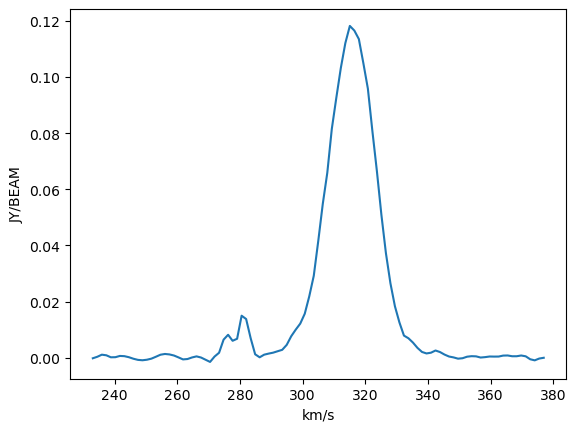

In [4]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

file = fits.open('ngc6946.fits') # opening the file
hdr = file[0].header

data = file[0].data  # the 0 extension contains the image data

Z = data[:,55,58] # velocity profile at RA = 58 and Dec = 55 
X = np.linspace(233,377,Z.size) # redefined x axis


fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(X,Z)
frame.set_xlabel(hdr['CUNIT3'])
frame.set_ylabel(hdr['BUNIT'])
fig.show()


In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [6]:
def fsy(x, amp, mu, sigma, zero): #compatible with sympy, using sympy.exp
    '''
    The function returns the value of a Gaussian function with the given parameters.
    Params: x (array-like) the domain of the function
            amp (float) the amplitude of the Gaussian function
            mu (float) the position of the center of the Gaussian function
            sigma (float) the width of the Gaussian function
            zero (float) offset with respect to the x axis
    Return: the value of the distribution
    '''

    gauss = amp*sympy.exp(-(x-mu)**2/(2*sigma**2))+zero

    return gauss    

def fnp(x, amp, mu, sigma, zero): # compatible with numpy, using numpy.exp
    '''
    The function returns the value of a Gaussian function with the given parameters.
    Params: x (array-like) the domain of the function
            amp (float) the amplitude of the Gaussian function
            mu (float) the position of the center of the Gaussian function
            sigma (float) the width of the Gaussian function
            zero (float) offset with respect to the x axis
    Return: the value of the distribution
    '''

    gauss = amp*np.exp(-(x-mu)**2/(2*sigma**2))+zero

    return gauss  

In [7]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

In [8]:
import sympy
from sympy import Symbol

x = sympy.Symbol('x') # defining the variables so that sympy recognises them
amp = sympy.Symbol('amp')
mu = sympy.Symbol('mu')
sigma = sympy.Symbol('sigma')
zero = sympy.Symbol('zero')

f = fsy(x,amp,mu,sigma,zero) # calling the function

dmu = sympy.diff(f,mu)
print("Partial derivative of the Gaussian with respect to the mean:", dmu) # we can see that mu is in the derivative therefore the function is not linear

Partial derivative of the Gaussian with respect to the mean: -amp*(2*mu - 2*x)*exp(-(-mu + x)**2/(2*sigma**2))/(2*sigma**2)


In [9]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [10]:
import scipy
from scipy.optimize import curve_fit
    
amp = 0.12 # they can be estimated from the plot in 1 by approximately reading off their values.
mu = 315
sigma = 10
zero = 0

param,cov = curve_fit(fnp,X,Z,p0 = (amp,mu,sigma,zero)) # this function gives the values of the parameters of the fit and their errors

error = np.sqrt(np.diag(cov)) # scaling the errors

amp = param[0]
mu = param[1]
sigma = param[2]
zero = param[3]
print(amp, mu, sigma, zero) # extracting the fitted parameters

0.11693859387406887 315.7168476367103 7.2610659144183805 0.0013435918980946062


In [11]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

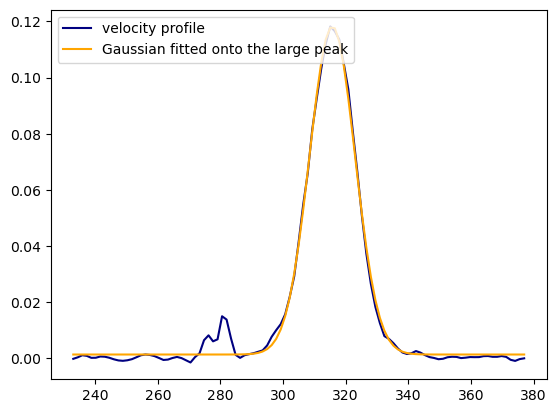

In [12]:
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(X,Z,color = 'navy', label = 'velocity profile')
frame.plot(X,fnp(X,amp,mu,sigma,zero), label = "Gaussian fitted onto the large peak", color = 'orange')
frame.legend(loc = 'upper left')
fig.show()

In [13]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

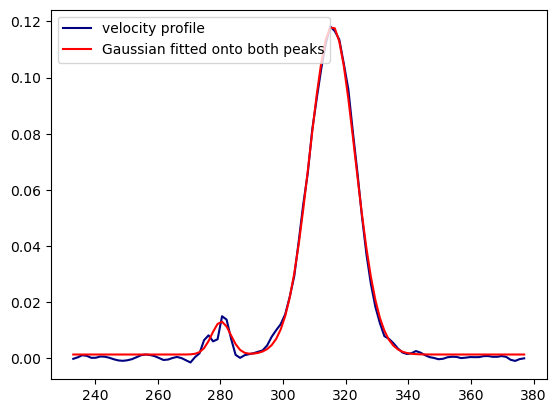

In [14]:
amp2 = 0.02 # they can be estimated from the plot in 1 by reading off their approximate values. zero is the same as for the main peak
mu2 = 280
sigma2 = 3

def fnp_small(x, amp, mu, sigma,zero,amp2,mu2,sigma2): # defining the composed function that fits the sum of two gaussians onto the two peaks
    '''
    The function returns the value of a Gaussian function with the given parameters.
    Params: x (array-like) the domain of the function
            amp (float) the amplitude of the Gaussian function
            mu (float) the position of the center of the Gaussian function
            sigma (float) the width of the Gaussian function
    Return: the value of the distribution
    '''

    gauss = fnp(x,amp,mu,sigma,zero)+fnp(x,amp2,mu2,sigma2,0) # zero2=0 since it is the same as for the main peak

    return gauss  

# using curve fit as during fitting the main peak: 
param2,cov2 = curve_fit(fnp_small,X,Z,p0 = (amp,mu,sigma,zero,amp2,mu2,sigma2)) 

error2 = np.sqrt(np.diag(cov2))

amp2 = param2[4] # extracting the values of the parameters from the output of curve_fit
mu2 = param2[5]
sigma2 = param2[6]

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(X,Z,color = 'navy', label = 'velocity profile')
frame.plot(X,fnp_small(X,amp,mu,sigma,zero,amp2,mu2,sigma2), label = "Gaussian fitted onto both peaks", color = 'red')
frame.legend()
fig.show()

In [15]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [16]:
# calculating the FWHM and its error for both peaks from formulas on brightspace
FWHM1 = 2*sigma*np.sqrt(2*np.log(2))

dFWHM1 = 2*error2[2]*np.sqrt(2*np.log(2)) # the error of sigma is extracted from the result of the fit of the composite gaussian

FWHM2 = 2*sigma2*np.sqrt(2*np.log(2))

dFWHM2 = 2*error2[6]*np.sqrt(2*np.log(2))

print(fr"The FWHM of the main peak is: ({FWHM1:.2f} " +"+-"+ f" {dFWHM1:.2f}) {hdr['CUNIT3']}.")
print(fr"The FWHM of the secondary peak is: ({FWHM2:.2f} " +"+-"+ f" {dFWHM2:.2f}) {hdr['CUNIT3']}.")

The FWHM of the main peak is: (17.10 +- 0.11) km/s.
The FWHM of the secondary peak is: (7.12 +- 0.68) km/s.


In [17]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

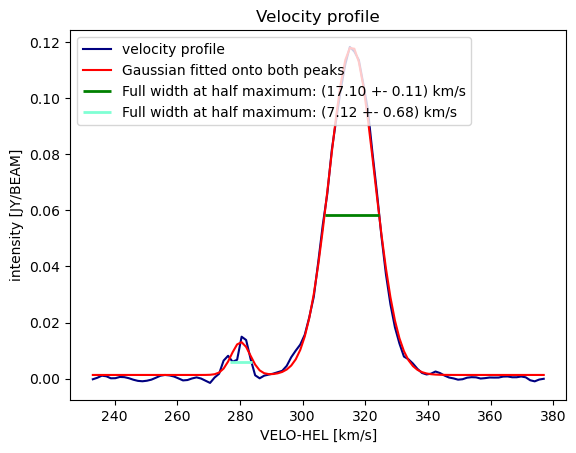

In [18]:
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.set_title("Velocity profile")
frame.set_xlabel(hdr['CTYPE3']+f" [{hdr['CUNIT3']}]")
frame.set_ylabel(hdr['BTYPE'] +f" [{hdr['BUNIT']}]")
frame.plot(X,Z,color = 'navy', label = "velocity profile")
frame.plot(X,fnp_small(X,amp,mu,sigma,zero,amp2,mu2,sigma2), label = "Gaussian fitted onto both peaks", color = 'red')
# creating horizontal lines for FWHMs
frame.hlines(y =(amp/2),xmin = (mu - FWHM1/2),xmax = (mu + FWHM1/2),color = 'green',linewidth = 2, label = f"Full width at half maximum: ({FWHM1:.2f} " +"+-"+ f" {dFWHM1:.2f}) {hdr['CUNIT3']}")
frame.hlines(y =(amp2/2),xmin = (mu2 - FWHM2/2),xmax = (mu2 + FWHM2/2),color = 'aquamarine',linewidth = 2, label = f"Full width at half maximum: ({FWHM2:.2f} " +"+-"+ f" {dFWHM2:.2f}) {hdr['CUNIT3']}")
frame.legend(loc = 'upper left')
fig.show()

In [19]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   ![image.png](attachment:2f684ef4-1ed4-4827-b0e4-a6bd194ca61c.png)    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

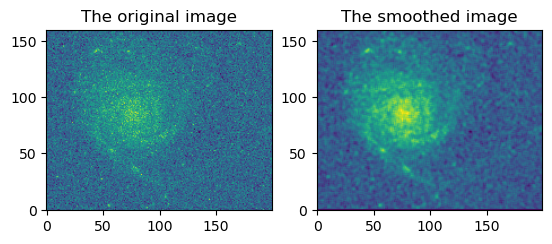

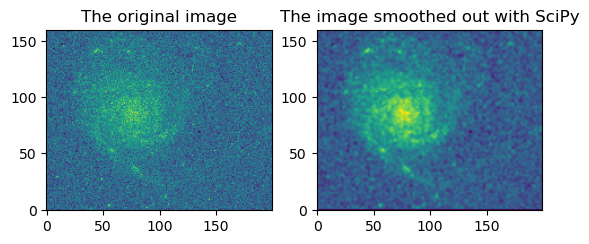

In [20]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from scipy import ndimage

def smooth(M):
    '''
    This function smoothes out a picture.
    Params: M (image data, 2d array) the data of the image that needs to be smoothed out
    Return: Mc (image data, 2d array) the smoothed-out picture
    '''
    Mc = np.zeros(np.shape(M))
    for j in range(1, np.shape(M)[0]-1):
        for i in range(1, np.shape(M)[1]-1):
            Mc[j,i] = np.mean(M[j-1:j+2,i-1:i+2])
    return Mc

file = fits.open('faintgalaxy.fits') # opening fits file
hdr = file[0].header
data = file[0].data
M = data

fig = figure()
frame = fig.add_subplot(1,2,1) # creating a mosaic of two plots
frame.imshow(M, origin = 'lower') # adjusting origin
frame.set_title('The original image')

Mc = smooth(M)

frame2 = fig.add_subplot(1,2,2)
frame2.imshow(Mc, origin = 'lower')
frame2.set_title('The smoothed image')
fig.show()

def smooth2(M): # using the given function
    Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
    return Mc

fig2 = figure()
frame3 = fig2.add_subplot(1,2,1)
frame3.imshow(M, origin = 'lower')
frame3.set_title('The original image')

Mc2 = smooth2(M)

frame4 = fig2.add_subplot(1,2,2)
frame4.imshow(Mc, origin = 'lower')
frame4.set_title('The image smoothed out with SciPy')
fig2.show()


In [21]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [22]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 25. Student score: 0.0.  Task Grade = 0.0
